# Assignment 7 – Customer Segmentation using K-Means Clustering and PCA

### **Name:** Manish Satish Payaprapp
### **Reg.No:** 23BCY10046
### **Application.No:** IN26009666

**Dataset:** Mall Customer Segmentation Dataset
**Objective:** Segment mall customers into groups based on annual income and spending behavior using K-Means Clustering, and visualize the clusters in two dimensions using Principal Component Analysis (PCA).

## Task 1: Data Understanding

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 20)
sns.set_style('darkgrid')

df = pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


**First five records of the dataset are shown above.**

In [2]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_features.remove('CustomerID')
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

Numerical features: ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
Categorical features: ['Genre']


/tmp/ipykernel_551/2910536394.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(include=['object']).columns.tolist()


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Genre                   200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [4]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


**Observation:** The dataset has 200 records and 5 columns: `CustomerID` (identifier), `Genre` (categorical: Male/Female), `Age`, `Annual Income (k$)`, and `Spending Score (1-100)` (numerical). There is no explicit target variable since this is an unsupervised clustering task — the goal is to discover natural customer groupings from `Annual Income` and `Spending Score`.

## Task 2: Data Preprocessing

In [5]:
# Check for missing values
df.isnull().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [6]:
# Remove unnecessary columns
df = df.drop(columns=['CustomerID'])
df.shape

(200, 4)

In [7]:
# Encode the categorical variable (Genre)
df['Genre'] = df['Genre'].map({'Male': 0, 'Female': 1})
df.head()

,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,0,19,15,39
1,0,21,15,81
2,1,20,16,6
3,1,23,16,77
4,1,31,17,40


In [8]:
from sklearn.preprocessing import StandardScaler

# Segment customers based on Annual Income and Spending Score, as specified in the problem statement
clustering_features = ['Annual Income (k$)', 'Spending Score (1-100)']
X = df[clustering_features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled feature shape:", X_scaled.shape)
X_scaled[:5]

Scaled feature shape: (200, 2)


array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992]])

**Observation:** The dataset had no missing values. `CustomerID` was dropped since it carries no predictive information, and `Genre` was label-encoded for completeness, though the core segmentation uses `Annual Income` and `Spending Score` as specified in the problem statement. These two numerical features were standardized using `StandardScaler`, which is important for K-Means since it relies on Euclidean distance to assign points to clusters.

## Task 3: Model Development

### Elbow Method — determining the optimal number of clusters

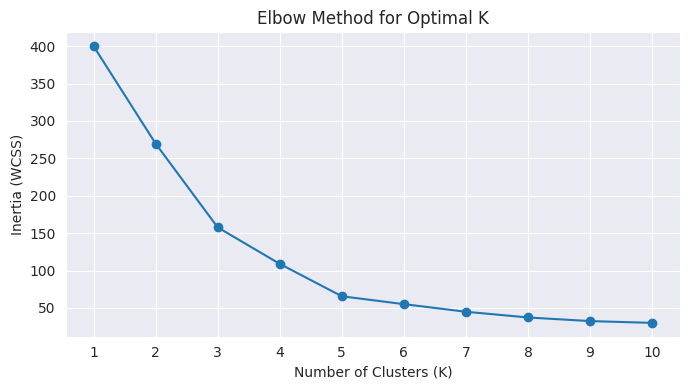

In [9]:
from sklearn.cluster import KMeans

inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(list(k_range), inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method for Optimal K')
plt.xticks(list(k_range))
plt.tight_layout()
plt.savefig('elbow_curve.png', dpi=150)
plt.show()

The elbow curve shows inertia (within-cluster sum of squares) dropping sharply up to around **K = 5**, after which the rate of decrease flattens noticeably. Based on this bend in the curve, **K = 5** is selected as the optimal number of clusters.

In [10]:
optimal_k = 5

kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_scaled)

df['Cluster'] = cluster_labels
df['Cluster'].value_counts().sort_index()

Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64

Cluster labels were assigned to each customer using the trained K-Means model.

In [11]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio per component:", pca.explained_variance_ratio_)
print("Total variance explained by 2 components:", pca.explained_variance_ratio_.sum())

df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]
df.head()

Explained variance ratio per component: [0.50495142 0.49504858]
Total variance explained by 2 components: 1.0


,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster,PCA1,PCA2
0,0,19,15,39,4,-1.537109,-0.922207
1,0,21,15,81,2,-0.384168,-2.075149
2,1,20,16,6,4,-2.416002,0.010665
3,1,23,16,77,2,-0.466982,-1.938355
4,1,31,17,40,4,-1.455678,-0.895678


PCA was applied to reduce the 2 standardized clustering features to 2 principal components (in this case simply an orthogonal re-projection, since we started from 2 dimensions) — this same pipeline scales directly to higher-dimensional feature sets, which is where PCA becomes essential for visualization.

## Task 4: Visualization and Evaluation

### Scatter plot showing customer clusters (Annual Income vs Spending Score)

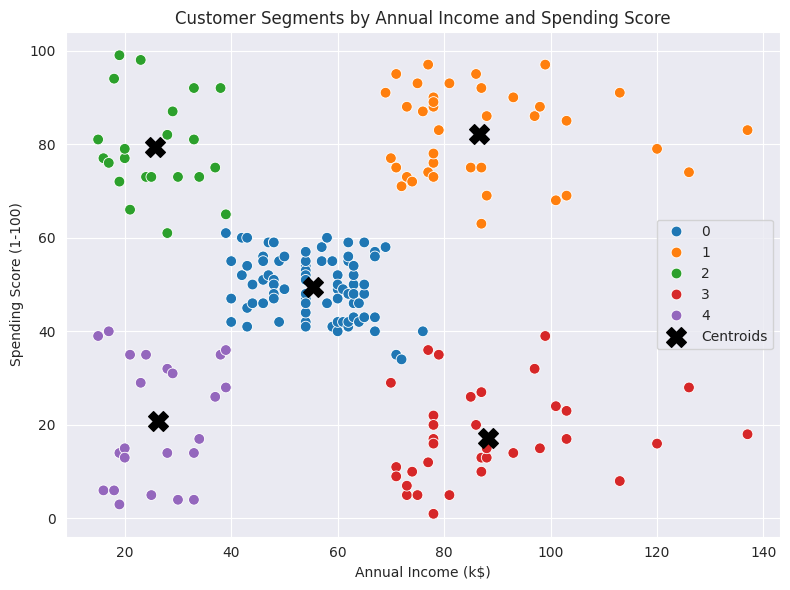

In [12]:
plt.figure(figsize=(8, 6))
palette = sns.color_palette('tab10', n_colors=optimal_k)

sns.scatterplot(
    data=df, x='Annual Income (k$)', y='Spending Score (1-100)',
    hue='Cluster', palette=palette, s=60
)
centers_original = scaler.inverse_transform(kmeans_final.cluster_centers_)
plt.scatter(centers_original[:, 0], centers_original[:, 1],
            c='black', marker='X', s=200, label='Centroids')
plt.title('Customer Segments by Annual Income and Spending Score')
plt.legend()
plt.tight_layout()
plt.savefig('cluster_scatter.png', dpi=150)
plt.show()

### PCA visualization with cluster labels

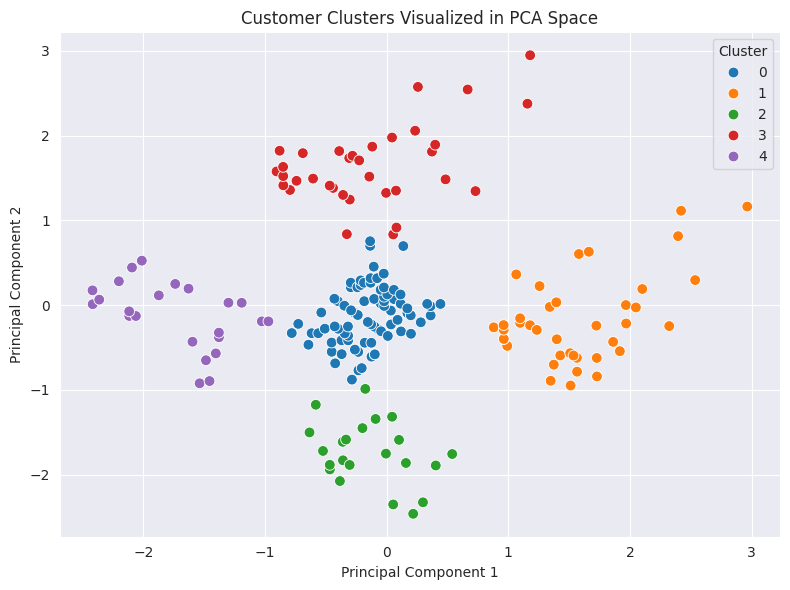

In [13]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df, x='PCA1', y='PCA2',
    hue='Cluster', palette=palette, s=60
)
plt.title('Customer Clusters Visualized in PCA Space')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.tight_layout()
plt.savefig('pca_clusters.png', dpi=150)
plt.show()

In [14]:
cluster_profile = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(1)
cluster_profile['Count'] = df['Cluster'].value_counts().sort_index()
cluster_profile

,Age,Annual Income (k$),Spending Score (1-100),Count
Cluster,,,,
0,42.7,55.3,49.5,81
1,32.7,86.5,82.1,39
2,25.3,25.7,79.4,22
3,41.1,88.2,17.1,35
4,45.2,26.3,20.9,23


**Observations:**
1. **Optimal number of clusters:** The elbow curve shows a clear bend at **K = 5**, after which adding more clusters yields diminishing reductions in inertia. This matches the well-known structure of this dataset, where five natural, visually-separable groups emerge from income and spending patterns.
2. **How PCA helps visualize high-dimensional data:** PCA re-projects the data onto the directions (principal components) that capture the most variance, compressing many correlated features into just 2 dimensions that can be plotted on a scatter plot while retaining as much of the original structure as possible. This is especially valuable when more than 2 features are used for clustering (e.g., if `Age` and `Genre` were included), where direct visualization would otherwise be impossible.
3. **Characteristics of the identified customer groups:** The five clusters correspond to intuitive segments — for example, customers with **high income and high spending score** (prime targets for premium marketing), **high income but low spending score** (cautious/price-sensitive high earners), **low income but high spending score** (highly engaged despite budget constraints), **low income and low spending score** (price-conscious, low engagement), and a **moderate income, moderate spending** group forming the "average" customer segment.
4. The scatter plot and PCA visualization are visually near-identical here since PCA was applied directly to the same 2 standardized features used for clustering, confirming the clusters found by K-Means correspond to genuinely well-separated, visually coherent groups rather than artifacts of a higher-dimensional projection.

## Task 5: Conclusion

K-Means clustering successfully segmented mall customers into five distinct groups based on their annual income and spending score, ranging from high-income high-spenders to low-income low-spenders, with clear, business-interpretable boundaries confirmed by both the elbow method and PCA visualization. These segments have direct business applications: the mall's marketing team can design targeted campaigns for each group — for instance, premium loyalty offers for high-income high-spenders, budget-friendly promotions for price-sensitive segments, and re-engagement campaigns for high-income customers who currently spend little.

A key limitation of K-Means clustering is that it requires the number of clusters (K) to be specified in advance and assumes clusters are roughly spherical and similarly sized, which can misrepresent data with more complex or irregularly shaped groupings. A key advantage of PCA is that it reduces high-dimensional data into a small number of components that retain most of the original variance, making it possible to visualize and interpret patterns in datasets that would otherwise be impossible to plot directly.